In [18]:
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [19]:
import pandas as pd

df = pd.read_csv("creditcard.csv")
print(df.shape)

(284807, 31)


In [20]:
# Count of each class
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [21]:

df['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


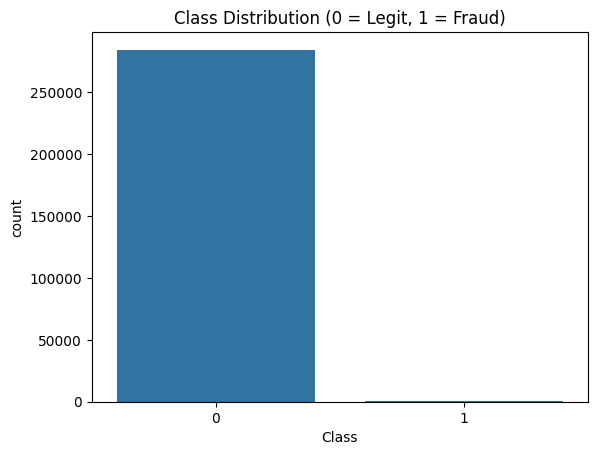

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.show()

The class distribution plot clearly shows extreme imbalance, where fraudulent transactions are almost negligible compared to legitimate ones. This justifies the need for imbalance handling techniques like SMOTE and recall-focused evaluation.

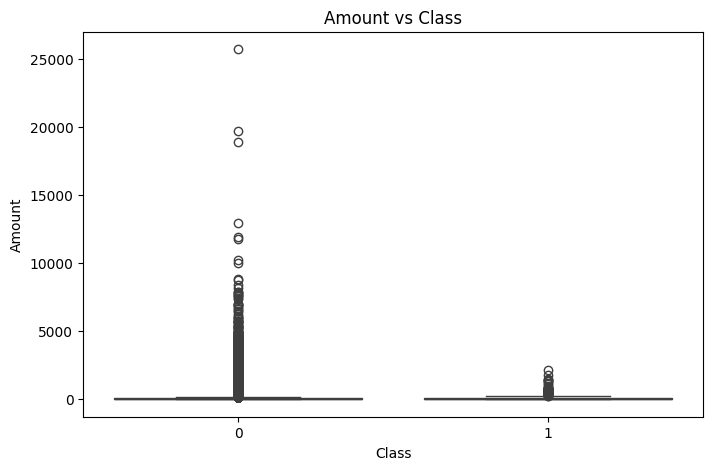

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount vs Class")
plt.show()

The boxplot shows that fraudulent transactions generally occur at lower amounts compared to legitimate transactions. However, there are significant outliers in legitimate transactions, indicating high-value normal transactions.

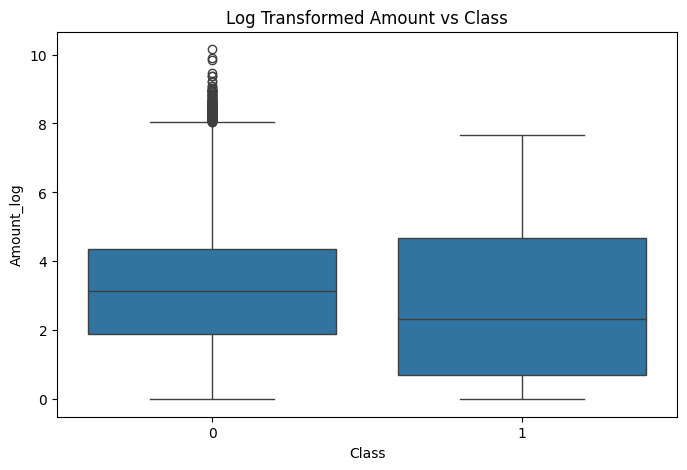

In [24]:
import numpy as np

# Log transform
df['Amount_log'] = np.log1p(df['Amount'])

# Plot after transformation
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount_log', data=df)
plt.title("Log Transformed Amount vs Class")
plt.show()

After applying log transformation, the distribution of transaction amounts becomes more normalized, reducing skewness and making patterns between fraud and legitimate transactions clearer


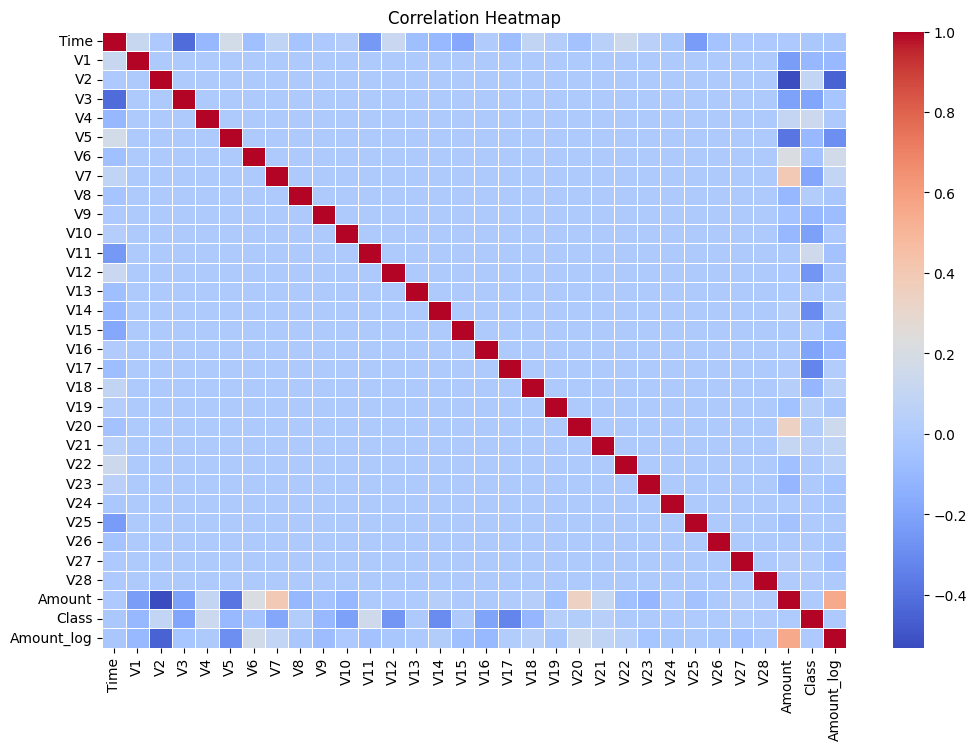

In [25]:
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [26]:
# Correlation with target
corr_target = df.corr()['Class'].sort_values(ascending=False)

# Show top positive & negative correlations
print(corr_target.head(10))
print("------")
print(corr_target.tail(10))

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64
------
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


🔴 Top POSITIVE correlation with Fraud:
V11, V4, V2 → increase → higher fraud probability
🔵 Top NEGATIVE correlation:
V17, V14, V12, V10 → decrease → higher fraud probability

Features such as V14, V17, and V12 show strong negative correlation with fraud, indicating they are highly important in distinguishing fraudulent transactions. These features will significantly influence model performance.

In [27]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop(['Class'], axis=1)
y = df['Class']

# Split (IMPORTANT: stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (227845, 31)
Test shape: (56962, 31)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


We applied SMOTE to synthetically generate minority class samples, balancing the dataset and enabling the model to learn fraud patterns effectively.
SMOTE was applied only on training data to prevent data leakage

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9713266813478345


# the Logistic Regression model achieves high recall (0.92), making it effective at detecting fraudulent transactions. However, it suffers from very low precision, indicating a high number of false positives.

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9745382466436209


Random Forest significantly improves precision while maintaining high recall, resulting in a well-balanced fraud detection model with strong overall performance.

In [31]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.63      0.85      0.72        98

    accuracy                           1.00     56962
   macro avg       0.82      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9776473476278524


Although XGBoost achieved the highest ROC-AUC, Random Forest provided the best balance between precision and recall, making it more suitable for real-world fraud detection where both false positives and false negatives are critical.

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['Precision', 'Recall']
)

history = model.fit(
    X_train_resampled, y_train_resampled,
    epochs=10,
    batch_size=1024,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - Precision: 0.9399 - Recall: 0.9110 - loss: 0.1428 - val_Precision: 1.0000 - val_Recall: 0.9656 - val_loss: 0.0857
Epoch 2/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - Precision: 0.9789 - Recall: 0.9724 - loss: 0.0503 - val_Precision: 1.0000 - val_Recall: 0.9886 - val_loss: 0.0379
Epoch 3/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Precision: 0.9852 - Recall: 0.9884 - loss: 0.0301 - val_Precision: 1.0000 - val_Recall: 0.9994 - val_loss: 0.0153
Epoch 4/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Precision: 0.9898 - Recall: 0.9955 - loss: 0.0197 - val_Precision: 1.0000 - val_Recall: 0.9999 - val_loss: 0.0088
Epoch 5/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Precision: 0.9923 - Recall: 0.9979 - loss: 0.0144 - val_Precision: 1.0000 - val_Recall: 1.0000 - val_loss: 0.0059
Epoch 6/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Precision: 0.9939 - Recall: 0.9991 - loss: 0.0111 - val_Precision: 1.0000 - val_Recall: 1.0000 - val_loss

In [33]:
# Predictions on REAL test data
y_prob_ann = model.predict(X_test_scaled)
y_pred_ann = (y_prob_ann > 0.5).astype(int)

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_ann))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_ann))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.87      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9774447518174406


Random Forest was selected as the final model because it provides the best balance between precision and recall, achieving the highest F1-score (0.85). While XGBoost and ANN achieved slightly higher ROC-AUC, they had lower precision, making Random Forest more suitable for real-world fraud detection.

In [34]:
final_prob = (y_prob_rf + y_prob_xgb) / 2
final_pred = (final_prob > 0.5).astype(int)

In [35]:
import joblib

joblib.dump(rf, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [52]:
%%writefile app.py

import streamlit as st
import joblib
import numpy as np

# Load model
model = joblib.load("fraud_model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("💳 Credit Card Fraud Detection")

st.write("Enter transaction features:")

features = []
for i in range(30):
    val = st.number_input(f"Feature {i+1}", value=0.0)
    features.append(val)

if st.button("Predict"):
    features = np.array(features).reshape(1, -1)
    features_scaled = scaler.transform(features)

    pred = model.predict(features_scaled)[0]
    prob = model.predict_proba(features_scaled)[0][1]

    if pred == 1:
        st.error(f"⚠️ Fraud Detected (Probability: {prob:.2f})")
    else:
        st.success(f"✅ Legit Transaction (Probability: {prob:.2f})")

Overwriting app.py
